In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

warnings.filterwarnings("ignore")

In [2]:
PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "data"
FEATURE_DIR = DATA_DIR / "features"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

old_features_path = FEATURE_DIR / "ptb_detection_handcrafted_features_with_split.csv"
advanced_features_path = FEATURE_DIR / "ptb_detection_advanced_fiducial_features.csv"

print("Project directory:", PROJECT_DIR)
print("Old features:", old_features_path, old_features_path.exists())
print("Advanced features:", advanced_features_path, advanced_features_path.exists())

Project directory: d:\HUST\ET4248E - Học máy trong y tế\Final Project
Old features: d:\HUST\ET4248E - Học máy trong y tế\Final Project\data\features\ptb_detection_handcrafted_features_with_split.csv True
Advanced features: d:\HUST\ET4248E - Học máy trong y tế\Final Project\data\features\ptb_detection_advanced_fiducial_features.csv True


In [3]:
PURPLE_MAIN = "#C599B6"
PURPLE_DARK = "#8A5A78"
PURPLE_LIGHT = "#E8D3DF"
PURPLE_MID = "#B77FA0"
RED_SOFT = "#C44E52"
GRAY = "#6B6B6B"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [4]:
old_df = pd.read_csv(old_features_path)
adv_df = pd.read_csv(advanced_features_path)

print("Old feature table shape:", old_df.shape)
print("Advanced feature table shape:", adv_df.shape)

display(old_df.head())
display(adv_df.head())

print("\nOld split counts:")
display(old_df["split"].value_counts())

print("\nAdvanced extraction status:")
display(adv_df["extraction_status"].value_counts())

Old feature table shape: (448, 1423)
Advanced feature table shape: (448, 2579)


,patient_id,record_id,record_path,mi_detected,healthy_control,reason_for_admission,extraction_status,error_message,fs,duration_sec,...,contrast_lateral_over_chest_morph_qrs_ptp_mean,contrast_lateral_minus_chest_morph_st_level_mean,contrast_lateral_over_chest_morph_st_level_mean,contrast_lateral_minus_chest_morph_t_amp_mean,contrast_lateral_over_chest_morph_t_amp_mean,contrast_lateral_minus_chest_ratio_abs_st_to_qrs,contrast_lateral_over_chest_ratio_abs_st_to_qrs,contrast_lateral_minus_chest_ratio_abs_t_to_qrs,contrast_lateral_over_chest_ratio_abs_t_to_qrs,split
0,patient001,s0010_re,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,1,0,Myocardial infarction,success,NaN,1000,38.4,...,0.869859,-0.113679,-1.232628,-0.277465,-1.848635,0.028838,1.397076,0.076624,1.332658,train
1,patient001,s0014lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,1,0,Myocardial infarction,success,NaN,1000,115.2,...,0.919469,-0.071970,-1.296162,-0.036523,0.432207,0.011147,1.290027,0.047875,1.497575,train
2,patient001,s0016lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,1,0,Myocardial infarction,success,NaN,1000,115.2,...,0.914905,-0.191350,-1.982390,0.611210,0.365668,0.019226,1.461171,0.034442,1.445004,train
3,patient002,s0015lre,ptb-diagnostic-ecg-database-1.0.0\patient002\s...,1,0,Myocardial infarction,success,NaN,1000,115.2,...,0.992804,-0.154674,-3.082995,0.024435,-0.989664,0.032816,3.750345,0.080275,1.202903,test
4,patient003,s0017lre,ptb-diagnostic-ecg-database-1.0.0\patient003\s...,1,0,Myocardial infarction,success,NaN,1000,115.2,...,1.185153,-0.406936,-3.138080,-0.857880,0.563911,-0.032781,0.577757,-0.252801,0.530411,train


,patient_id,record_id,record_path,reason_for_admission,mi_detected,healthy_control,extraction_status,error_message,fs,duration_sec,...,contrast_chest_minus_limb_adv_st_level_j80_mean,contrast_inferior_minus_anterior_adv_t_amp_mean,contrast_lateral_minus_anterior_adv_t_amp_mean,contrast_chest_minus_limb_adv_t_amp_mean,contrast_inferior_minus_anterior_adv_q_amp_mean,contrast_lateral_minus_anterior_adv_q_amp_mean,contrast_chest_minus_limb_adv_q_amp_mean,contrast_inferior_minus_anterior_adv_qrs_ptp_amp_mean,contrast_lateral_minus_anterior_adv_qrs_ptp_amp_mean,contrast_chest_minus_limb_adv_qrs_ptp_amp_mean
0,patient001,s0010_re,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,Myocardial infarction,1,0,success,NaN,1000,38.4,...,-0.372797,-2.886837,-0.929231,0.238442,-2.930195,-1.388442,1.262988,-3.210493,-1.605038,1.447418
1,patient001,s0014lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,Myocardial infarction,1,0,success,NaN,1000,115.2,...,-0.280683,-1.682576,-0.277867,0.130424,-3.572690,-2.157368,0.329603,-2.015850,-0.843633,1.508595
2,patient001,s0016lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,Myocardial infarction,1,0,success,NaN,1000,115.2,...,-0.264795,-0.525104,0.696495,-0.445783,-3.347961,-1.438515,0.427154,-1.960238,-0.952725,1.337776
3,patient002,s0015lre,ptb-diagnostic-ecg-database-1.0.0\patient002\s...,Myocardial infarction,1,0,success,NaN,1000,115.2,...,-0.327763,5.337668,0.346021,-2.703355,1.828850,1.855689,-0.718491,-0.586200,0.446828,0.586184
4,patient003,s0017lre,ptb-diagnostic-ecg-database-1.0.0\patient003\s...,Myocardial infarction,1,0,success,NaN,1000,115.2,...,0.584071,-6.506432,-2.005458,2.654946,-1.514142,-0.551029,1.496457,-1.033743,1.852081,0.523803



Old split counts:


split
train         308
validation     72
test           68
Name: count, dtype: int64


Advanced extraction status:


extraction_status
success    448
Name: count, dtype: int64

In [5]:
split_cols = old_df[["patient_id", "record_id", "split"]].copy()

adv_df = adv_df.merge(
    split_cols,
    on=["patient_id", "record_id"],
    how="left"
)

print("Advanced table after merging split:", adv_df.shape)

print("\nMissing split:")
display(adv_df["split"].isna().value_counts())

print("\nSplit counts:")
display(adv_df["split"].value_counts())

print("\nClass distribution by split:")
display(pd.crosstab(adv_df["split"], adv_df["mi_detected"]))

Advanced table after merging split: (448, 2580)

Missing split:


split
False    448
Name: count, dtype: int64


Split counts:


split
train         308
validation     72
test           68
Name: count, dtype: int64


Class distribution by split:


mi_detected,0,1
split,,
test,12,56
train,57,251
validation,11,61


In [6]:
def evaluate_binary_classifier(y_true, y_pred, y_score=None, model_name="", dataset_name=""):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    result = {
        "dataset": dataset_name,
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_mi": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_sensitivity_mi": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "specificity_healthy": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_mi": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

    if y_score is not None:
        try:
            result["roc_auc"] = roc_auc_score(y_true, y_score)
        except Exception:
            result["roc_auc"] = np.nan
    else:
        result["roc_auc"] = np.nan

    return result


def get_model_score(pipe, X):
    model = pipe.named_steps["model"]

    if hasattr(model, "predict_proba"):
        return pipe.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        return pipe.decision_function(X)
    else:
        return None

In [7]:
def plot_confusion_matrix_custom(cm, title, save_path=None):
    fig, ax = plt.subplots(figsize=(5.5, 5))

    im = ax.imshow(cm, cmap="PuRd")

    labels = ["Healthy Control", "MI"]

    ax.set_xticks(np.arange(2))
    ax.set_yticks(np.arange(2))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    max_value = cm.max()

    for i in range(2):
        for j in range(2):
            value = cm[i, j]
            text_color = "white" if value > max_value / 2 else "black"
            ax.text(
                j,
                i,
                str(value),
                ha="center",
                va="center",
                color=text_color,
                fontsize=14,
                fontweight="bold"
            )

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()

# Part A — Prepare Feature Columns

In [8]:
old_exclude_cols = [
    "patient_id",
    "record_id",
    "record_path",
    "reason_for_admission",
    "extraction_status",
    "error_message",
    "rpeak_detection_direction",
    "mi_detected",
    "healthy_control",
    "split",
    "fs",
    "duration_sec",
    "n_samples",
    "n_channels_original",
    "n_detected_rpeaks",
    "n_valid_beats",
    "beat_length_samples",
    "rhythm_n_detected_rpeaks",
    "rhythm_duration_sec"
]

old_numeric_cols = old_df.select_dtypes(include=[np.number]).columns.tolist()

old_feature_cols = [
    col for col in old_numeric_cols
    if col not in old_exclude_cols
]

remove_stat_keywords = [
    "_stat_mean",
    "_stat_std",
    "_stat_var",
    "_stat_rms",
    "_stat_energy"
]

old_clean_feature_cols = [
    col for col in old_feature_cols
    if not any(keyword in col for keyword in remove_stat_keywords)
]

print("Old all feature columns:", len(old_feature_cols))
print("Old clean feature columns:", len(old_clean_feature_cols))
print(old_clean_feature_cols[:30])

Old all feature columns: 1404
Old clean feature columns: 1304
['rhythm_hr_count', 'rhythm_hr_mean', 'rhythm_hr_median', 'rhythm_hr_std', 'rhythm_rr_mean', 'rhythm_rr_median', 'rhythm_rr_std', 'rhythm_rr_min', 'rhythm_rr_max', 'rhythm_rr_range', 'rhythm_rmssd', 'rhythm_pnn50', 'i_stat_median', 'i_stat_min', 'i_stat_max', 'i_stat_range', 'i_stat_abs_mean', 'i_stat_iqr', 'i_stat_skewness', 'i_stat_kurtosis', 'i_stat_entropy', 'i_stat_zcr', 'ii_stat_median', 'ii_stat_min', 'ii_stat_max', 'ii_stat_range', 'ii_stat_abs_mean', 'ii_stat_iqr', 'ii_stat_skewness', 'ii_stat_kurtosis']


In [9]:
adv_exclude_cols = [
    "patient_id",
    "record_id",
    "record_path",
    "reason_for_admission",
    "extraction_status",
    "error_message",
    "qrs_detection_direction",
    "mi_detected",
    "healthy_control",
    "split",
    "fs",
    "duration_sec",
    "n_samples",
    "n_detected_qrs_peaks",
    "n_valid_beats"
]

adv_numeric_cols = adv_df.select_dtypes(include=[np.number]).columns.tolist()

adv_feature_cols = [
    col for col in adv_numeric_cols
    if col not in adv_exclude_cols
]

print("Advanced feature columns:", len(adv_feature_cols))
print(adv_feature_cols[:30])

Advanced feature columns: 2565
['rhythm_hr_median', 'rhythm_rr_std', 'i_adv_q_amp_mean', 'i_adv_q_amp_median', 'i_adv_q_amp_std', 'i_adv_q_amp_min', 'i_adv_q_amp_max', 'i_adv_q_amp_iqr', 'i_adv_s_amp_mean', 'i_adv_s_amp_median', 'i_adv_s_amp_std', 'i_adv_s_amp_min', 'i_adv_s_amp_max', 'i_adv_s_amp_iqr', 'i_adv_q_time_mean', 'i_adv_q_time_median', 'i_adv_q_time_std', 'i_adv_q_time_min', 'i_adv_q_time_max', 'i_adv_q_time_iqr', 'i_adv_s_time_mean', 'i_adv_s_time_median', 'i_adv_s_time_std', 'i_adv_s_time_min', 'i_adv_s_time_max', 'i_adv_s_time_iqr', 'i_adv_qrs_peak_amp_mean', 'i_adv_qrs_peak_amp_median', 'i_adv_qrs_peak_amp_std', 'i_adv_qrs_peak_amp_min']


In [11]:
# Cell 10
compact_keywords = [
    "qrs_peak_abs_amp",
    "qrs_peak_amp",
    "qrs_max_amp",
    "qrs_min_amp",
    "qrs_ptp_amp",
    "qrs_duration_proxy",
    "st_level_j40",
    "st_level_j60",
    "st_level_j80",
    "st_slope",
    "st_area",
    "t_amp",
    "t_abs_amp",
    "t_polarity",
    "t_area",
    "t_qrs_peak_ratio",
    "st_qrs_peak_ratio",
    "q_qrs_ratio",
    "s_qrs_ratio",
    "qt_proxy",
    "qrs_to_t_peak"
]

adv_compact_cols = [
    col for col in adv_feature_cols
    if any(keyword in col for keyword in compact_keywords)
]

adv_group_cols = [
    col for col in adv_feature_cols
    if "_group_adv_" in col
]

adv_contrast_cols = [
    col for col in adv_feature_cols
    if col.startswith("contrast_")
]

adv_lead_specific_cols = [
    col for col in adv_feature_cols
    if any(col.startswith(prefix) for prefix in [
        "i_adv_", "ii_adv_", "iii_adv_", "avr_adv_", "avl_adv_", "avf_adv_",
        "v1_adv_", "v2_adv_", "v3_adv_", "v4_adv_", "v5_adv_", "v6_adv_"
    ])
]

print("Advanced compact columns:", len(adv_compact_cols))
print("Advanced group columns:", len(adv_group_cols))
print("Advanced contrast columns:", len(adv_contrast_cols))
print("Advanced lead-specific columns:", len(adv_lead_specific_cols))

Advanced compact columns: 1604
Advanced group columns: 100
Advanced contrast columns: 15
Advanced lead-specific columns: 2448


In [12]:
old_id_cols = ["patient_id", "record_id", "mi_detected", "healthy_control", "split"]

old_feature_prefixed_df = old_df[old_id_cols + old_clean_feature_cols].copy()
old_feature_prefixed_df = old_feature_prefixed_df.rename(
    columns={col: f"old__{col}" for col in old_clean_feature_cols}
)

adv_feature_prefixed_df = adv_df[["patient_id", "record_id"] + adv_feature_cols].copy()
adv_feature_prefixed_df = adv_feature_prefixed_df.rename(
    columns={col: f"adv__{col}" for col in adv_feature_cols}
)

combined_df = old_feature_prefixed_df.merge(
    adv_feature_prefixed_df,
    on=["patient_id", "record_id"],
    how="inner"
)

print("Combined dataframe shape:", combined_df.shape)

print("\nClass distribution:")
display(combined_df["mi_detected"].value_counts())

print("\nSplit counts:")
display(combined_df["split"].value_counts())

print("\nAny missing values?")
numeric_cols_combined = combined_df.select_dtypes(include=[np.number]).columns.tolist()
print(combined_df[numeric_cols_combined].isna().sum().sum())

display(combined_df.head())

Combined dataframe shape: (448, 3874)

Class distribution:


mi_detected
1    368
0     80
Name: count, dtype: int64


Split counts:


split
train         308
validation     72
test           68
Name: count, dtype: int64


Any missing values?
0


,patient_id,record_id,mi_detected,healthy_control,split,old__rhythm_hr_count,old__rhythm_hr_mean,old__rhythm_hr_median,old__rhythm_hr_std,old__rhythm_rr_mean,...,adv__contrast_chest_minus_limb_adv_st_level_j80_mean,adv__contrast_inferior_minus_anterior_adv_t_amp_mean,adv__contrast_lateral_minus_anterior_adv_t_amp_mean,adv__contrast_chest_minus_limb_adv_t_amp_mean,adv__contrast_inferior_minus_anterior_adv_q_amp_mean,adv__contrast_lateral_minus_anterior_adv_q_amp_mean,adv__contrast_chest_minus_limb_adv_q_amp_mean,adv__contrast_inferior_minus_anterior_adv_qrs_ptp_amp_mean,adv__contrast_lateral_minus_anterior_adv_qrs_ptp_amp_mean,adv__contrast_chest_minus_limb_adv_qrs_ptp_amp_mean
0,patient001,s0010_re,1,0,train,81.250000,81.783017,81.743869,1.028838,0.733765,...,-0.372797,-2.886837,-0.929231,0.238442,-2.930195,-1.388442,1.262988,-3.210493,-1.605038,1.447418
1,patient001,s0014lre,1,0,train,85.937500,86.252542,86.330935,0.644499,0.695671,...,-0.280683,-1.682576,-0.277867,0.130424,-3.572690,-2.157368,0.329603,-2.015850,-0.843633,1.508595
2,patient001,s0016lre,1,0,train,79.687500,79.868360,79.787234,1.035388,0.751362,...,-0.264795,-0.525104,0.696495,-0.445783,-3.347961,-1.438515,0.427154,-1.960238,-0.952725,1.337776
3,patient002,s0015lre,1,0,test,78.645833,78.919693,78.534031,2.228481,0.760860,...,-0.327763,5.337668,0.346021,-2.703355,1.828850,1.855689,-0.718491,-0.586200,0.446828,0.586184
4,patient003,s0017lre,1,0,train,71.875000,72.339710,72.289157,2.014078,0.830051,...,0.584071,-6.506432,-2.005458,2.654946,-1.514142,-0.551029,1.496457,-1.033743,1.852081,0.523803


In [13]:
old_prefixed_cols = [
    f"old__{col}" for col in old_clean_feature_cols
]

adv_all_prefixed_cols = [
    f"adv__{col}" for col in adv_feature_cols
]

adv_compact_prefixed_cols = [
    f"adv__{col}" for col in adv_compact_cols
]

adv_lead_specific_prefixed_cols = [
    f"adv__{col}" for col in adv_lead_specific_cols
]

adv_group_contrast_prefixed_cols = [
    f"adv__{col}" for col in adv_group_cols + adv_contrast_cols
]

feature_sets = {
    "Old clean only": old_prefixed_cols,
    "Advanced all only": adv_all_prefixed_cols,
    "Advanced compact only": adv_compact_prefixed_cols,
    "Old clean + advanced compact": old_prefixed_cols + adv_compact_prefixed_cols,
    "Old clean + advanced compact + group/contrast": old_prefixed_cols + adv_compact_prefixed_cols + adv_group_contrast_prefixed_cols,
    "Old clean + advanced all": old_prefixed_cols + adv_all_prefixed_cols
}

feature_set_summary = []

for name, cols in feature_sets.items():
    cols_unique = list(dict.fromkeys(cols))
    feature_sets[name] = cols_unique
    feature_set_summary.append({
        "feature_set": name,
        "n_features": len(cols_unique)
    })

feature_set_summary_df = pd.DataFrame(feature_set_summary)
display(feature_set_summary_df)

,feature_set,n_features
0,Old clean only,1304
1,Advanced all only,2565
2,Advanced compact only,1604
3,Old clean + advanced compact,2908
4,Old clean + advanced compact + group/contrast,2931
5,Old clean + advanced all,3869


In [14]:
train_df = combined_df[combined_df["split"] == "train"].copy()
val_df = combined_df[combined_df["split"] == "validation"].copy()
test_df = combined_df[combined_df["split"] == "test"].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nClass distribution by split:")
display(pd.crosstab(combined_df["split"], combined_df["mi_detected"]))

print("\nPatient leakage check:")
train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])
test_patients = set(test_df["patient_id"])

print("Train ∩ Val:", len(train_patients & val_patients))
print("Train ∩ Test:", len(train_patients & test_patients))
print("Val ∩ Test:", len(val_patients & test_patients))

Train shape: (308, 3874)
Validation shape: (72, 3874)
Test shape: (68, 3874)

Class distribution by split:


mi_detected,0,1
split,,
test,12,56
train,57,251
validation,11,61



Patient leakage check:
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


# Part B — Model Search

In [15]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=4000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ),
    "SVM RBF": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=False,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    )
}

k_values = [50, 100, 150, 200, 300, 500]

print("Models:", list(models.keys()))
print("k values:", k_values)

Models: ['Logistic Regression', 'SVM RBF', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'Hist Gradient Boosting']
k values: [50, 100, 150, 200, 300, 500]


In [16]:
validation_results = []
trained_pipelines = {}

for feature_set_name, cols in feature_sets.items():
    print("=" * 100)
    print("Feature set:", feature_set_name)
    print("Number of input features:", len(cols))

    X_train = train_df[cols].astype("float32")
    y_train = train_df["mi_detected"].astype(int)

    X_val = val_df[cols].astype("float32")
    y_val = val_df["mi_detected"].astype(int)

    for k in k_values:
        if k > len(cols):
            continue

        print(f"  k = {k}")

        for model_name, model in models.items():
            model_clone = clone(model)

            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("select", SelectKBest(score_func=f_classif, k=k)),
                ("model", model_clone)
            ])

            pipe.fit(X_train, y_train)

            y_val_pred = pipe.predict(X_val)
            y_val_score = get_model_score(pipe, X_val)

            result = evaluate_binary_classifier(
                y_val,
                y_val_pred,
                y_score=y_val_score,
                model_name=model_name,
                dataset_name="validation"
            )

            result["feature_set"] = feature_set_name
            result["n_input_features"] = len(cols)
            result["k_selected"] = k

            validation_results.append(result)
            trained_pipelines[(feature_set_name, k, model_name)] = pipe

validation_results_df = pd.DataFrame(validation_results)

print("Validation results shape:", validation_results_df.shape)

display(
    validation_results_df.sort_values(
        ["macro_f1", "roc_auc", "recall_sensitivity_mi"],
        ascending=False
    ).head(30)
)

Feature set: Old clean only
Number of input features: 1304
  k = 50
  k = 100
  k = 150
  k = 200
  k = 300
  k = 500
Feature set: Advanced all only
Number of input features: 2565
  k = 50
  k = 100
  k = 150
  k = 200
  k = 300
  k = 500
Feature set: Advanced compact only
Number of input features: 1604
  k = 50
  k = 100
  k = 150
  k = 200
  k = 300
  k = 500
Feature set: Old clean + advanced compact
Number of input features: 2908
  k = 50
  k = 100
  k = 150
  k = 200
  k = 300
  k = 500
Feature set: Old clean + advanced compact + group/contrast
Number of input features: 2931
  k = 50
  k = 100
  k = 150
  k = 200
  k = 300
  k = 500
Feature set: Old clean + advanced all
Number of input features: 3869
  k = 50
  k = 100
  k = 150
  k = 200
  k = 300
  k = 500
Validation results shape: (216, 17)


,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,tn,fp,fn,tp,roc_auc,feature_set,n_input_features,k_selected
31,validation,SVM RBF,0.930556,0.982759,0.934426,0.909091,0.957983,0.878992,0.921759,10,1,4,57,0.947839,Old clean only,1304,500
25,validation,SVM RBF,0.916667,0.966102,0.934426,0.818182,0.950000,0.850000,0.876304,9,2,4,57,0.946349,Old clean only,1304,300
26,validation,Random Forest,0.930556,0.924242,1.000000,0.545455,0.960630,0.833256,0.772727,6,5,0,61,0.975410,Old clean only,1304,300
19,validation,SVM RBF,0.902778,0.965517,0.918033,0.818182,0.941176,0.830588,0.868107,9,2,5,56,0.938897,Old clean only,1304,200
48,validation,Logistic Regression,0.888889,0.981818,0.885246,0.909091,0.931034,0.822660,0.897168,10,1,7,54,0.894188,Advanced all only,2565,150
78,validation,Logistic Regression,0.888889,0.981818,0.885246,0.909091,0.931034,0.822660,0.897168,10,1,7,54,0.891207,Advanced compact only,1604,100
7,validation,SVM RBF,0.875000,1.000000,0.852459,1.000000,0.920354,0.815016,0.926230,11,0,9,52,0.935917,Old clean only,1304,100
13,validation,SVM RBF,0.888889,0.964912,0.901639,0.818182,0.932203,0.812256,0.859911,9,2,6,55,0.934426,Old clean only,1304,150
30,validation,Logistic Regression,0.888889,0.964912,0.901639,0.818182,0.932203,0.812256,0.859911,9,2,6,55,0.913562,Old clean only,1304,500
42,validation,Logistic Regression,0.875000,0.981481,0.868852,0.909091,0.921739,0.805697,0.888972,10,1,8,53,0.912072,Advanced all only,2565,100


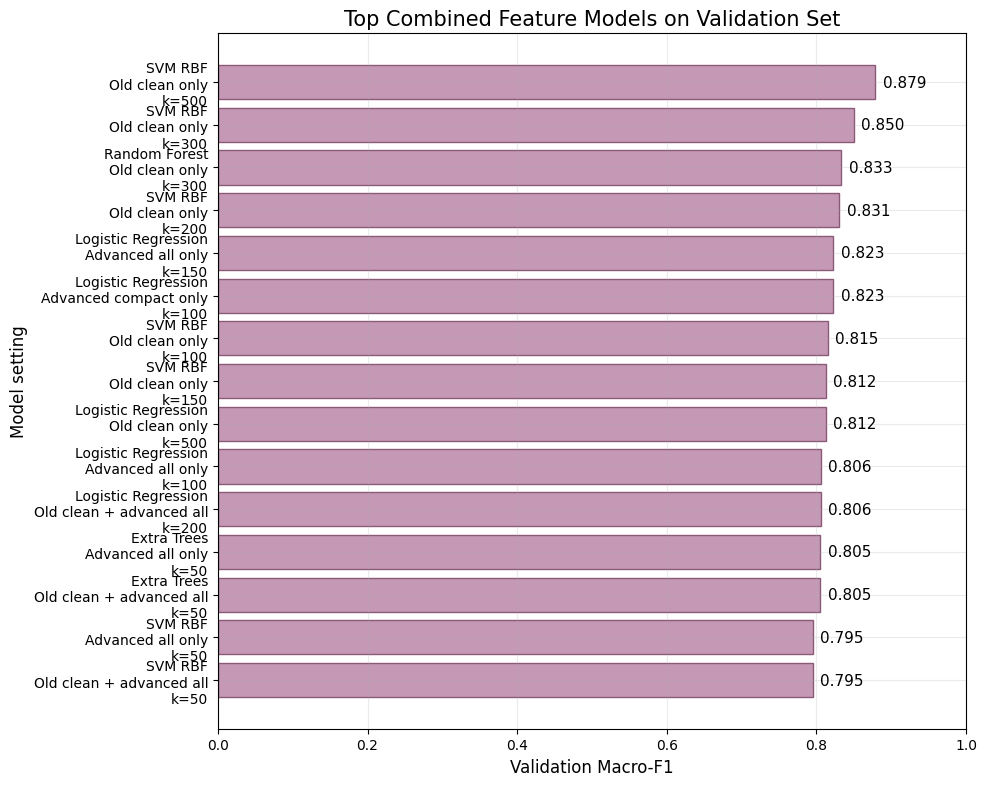

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6D_top_combined_validation_models.png


In [17]:
# Cell 16 - Plot top validation settings
top_val_df = validation_results_df.sort_values(
    ["macro_f1", "roc_auc", "recall_sensitivity_mi"],
    ascending=False
).head(15).copy()

top_val_df["display_name"] = (
    top_val_df["model"]
    + "\n"
    + top_val_df["feature_set"]
    + "\nk="
    + top_val_df["k_selected"].astype(str)
)

plt.figure(figsize=(10, 8))

bars = plt.barh(
    top_val_df["display_name"][::-1],
    top_val_df["macro_f1"][::-1],
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.title("Top Combined Feature Models on Validation Set")
plt.xlabel("Validation Macro-F1")
plt.ylabel("Model setting")
plt.xlim(0, 1)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center"
    )

plt.tight_layout()

fig_path = FIGURE_DIR / "notebook6D_top_combined_validation_models.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

In [20]:
best_val_row = validation_results_df.sort_values(
    ["macro_f1", "roc_auc", "recall_sensitivity_mi"],
    ascending=False
).iloc[0]

best_feature_set = best_val_row["feature_set"]
best_k = int(best_val_row["k_selected"])
best_model_name = best_val_row["model"]

best_pipe = trained_pipelines[(best_feature_set, best_k, best_model_name)]

print("Best combined model selected on validation:")
print("Feature set:", best_feature_set)
print("k:", best_k)
print("Model:", best_model_name)

display(best_val_row)

Best combined model selected on validation:
Feature set: Old clean only
k: 500
Model: SVM RBF


dataset                      validation
model                           SVM RBF
accuracy                       0.930556
precision_mi                   0.982759
recall_sensitivity_mi          0.934426
specificity_healthy            0.909091
f1_mi                          0.957983
macro_f1                       0.878992
balanced_accuracy              0.921759
tn                                   10
fp                                    1
fn                                    4
tp                                   57
roc_auc                        0.947839
feature_set              Old clean only
n_input_features                   1304
k_selected                          500
Name: 31, dtype: object

In [21]:
best_cols = feature_sets[best_feature_set]

X_test = test_df[best_cols].astype("float32")
y_test = test_df["mi_detected"].astype(int)

y_test_pred = best_pipe.predict(X_test)
y_test_score = get_model_score(best_pipe, X_test)

combined_test_result = evaluate_binary_classifier(
    y_test,
    y_test_pred,
    y_score=y_test_score,
    model_name=best_model_name,
    dataset_name="test"
)

combined_test_result["feature_set"] = best_feature_set
combined_test_result["k_selected"] = best_k
combined_test_result["n_input_features"] = len(best_cols)

combined_test_result_df = pd.DataFrame([combined_test_result])

print("Best combined model test result:")
display(combined_test_result_df)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Healthy Control", "MI"],
        zero_division=0
    )
)

Best combined model test result:


,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,tn,fp,fn,tp,roc_auc,feature_set,k_selected,n_input_features
0,test,SVM RBF,0.911765,1.0,0.892857,1.0,0.943396,0.871698,0.946429,12,0,6,50,0.952381,Old clean only,500,1304



Classification report:
                 precision    recall  f1-score   support

Healthy Control       0.67      1.00      0.80        12
             MI       1.00      0.89      0.94        56

       accuracy                           0.91        68
      macro avg       0.83      0.95      0.87        68
   weighted avg       0.94      0.91      0.92        68



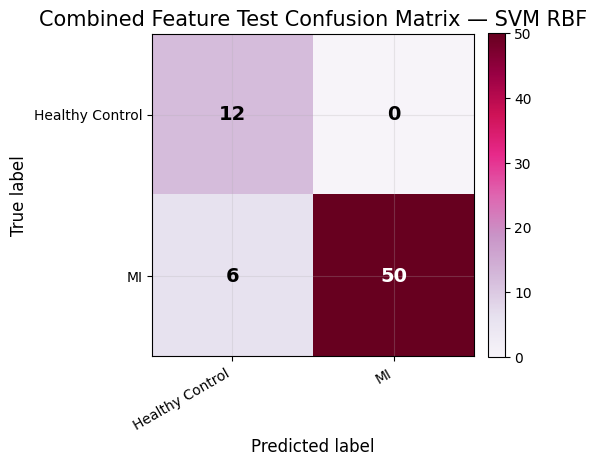

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6D_best_combined_test_confusion_matrix.png


In [22]:
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])

fig_path = FIGURE_DIR / "notebook6D_best_combined_test_confusion_matrix.png"

plot_confusion_matrix_custom(
    cm,
    title=f"Combined Feature Test Confusion Matrix — {best_model_name}",
    save_path=fig_path
)

print("Saved:", fig_path)

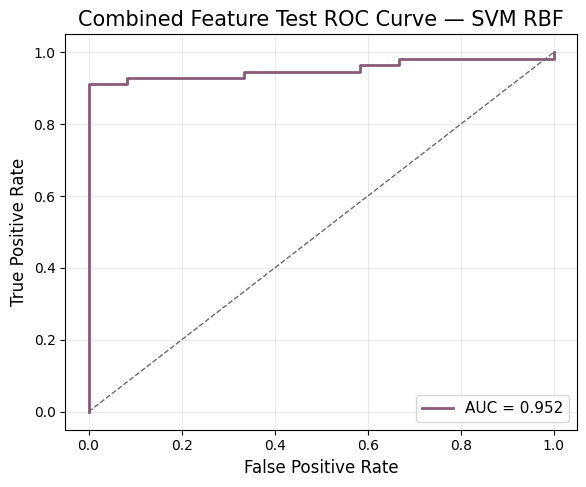

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6D_best_combined_test_roc_curve.png


In [23]:
if y_test_score is not None:
    fpr, tpr, thresholds = roc_curve(y_test, y_test_score)
    auc_value = roc_auc_score(y_test, y_test_score)

    plt.figure(figsize=(6, 5))

    plt.plot(
        fpr,
        tpr,
        color=PURPLE_DARK,
        linewidth=2,
        label=f"AUC = {auc_value:.3f}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color=GRAY,
        linewidth=1
    )

    plt.title(f"Combined Feature Test ROC Curve — {best_model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.25)
    plt.tight_layout()

    fig_path = FIGURE_DIR / "notebook6D_best_combined_test_roc_curve.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print("Saved:", fig_path)
else:
    print("No score available for ROC curve.")

# Part C — Compare with Previous Results

In [24]:
previous_results_df = pd.DataFrame([
    {
        "setting": "Old SVM baseline",
        "accuracy": 0.882353,
        "recall_sensitivity_mi": 0.910714,
        "specificity_healthy": 0.750000,
        "macro_f1": 0.809790,
        "roc_auc": 0.937500,
        "tn": 9,
        "fp": 3,
        "fn": 5,
        "tp": 51
    },
    {
        "setting": "Advanced Extra Trees",
        "accuracy": 0.897059,
        "recall_sensitivity_mi": 0.910714,
        "specificity_healthy": 0.833333,
        "macro_f1": 0.838260,
        "roc_auc": 0.929315,
        "tn": 10,
        "fp": 2,
        "fn": 5,
        "tp": 51
    },
    {
        "setting": "Record-wise Advanced Extra Trees",
        "accuracy": 0.911765,
        "recall_sensitivity_mi": 0.964286,
        "specificity_healthy": 0.666667,
        "macro_f1": 0.837321,
        "roc_auc": 0.950893,
        "tn": 8,
        "fp": 4,
        "fn": 2,
        "tp": 54
    }
])

combined_compare_row = {
    "setting": f"Combined features — {best_model_name}",
    "accuracy": combined_test_result["accuracy"],
    "recall_sensitivity_mi": combined_test_result["recall_sensitivity_mi"],
    "specificity_healthy": combined_test_result["specificity_healthy"],
    "macro_f1": combined_test_result["macro_f1"],
    "roc_auc": combined_test_result["roc_auc"],
    "tn": combined_test_result["tn"],
    "fp": combined_test_result["fp"],
    "fn": combined_test_result["fn"],
    "tp": combined_test_result["tp"]
}

comparison_df = pd.concat(
    [
        previous_results_df,
        pd.DataFrame([combined_compare_row])
    ],
    ignore_index=True
)

display(comparison_df)

comparison_path = TABLE_DIR / "notebook6D_combined_feature_comparison.csv"
comparison_df.to_csv(comparison_path, index=False, encoding="utf-8-sig")

print("Saved:", comparison_path)

,setting,accuracy,recall_sensitivity_mi,specificity_healthy,macro_f1,roc_auc,tn,fp,fn,tp
0,Old SVM baseline,0.882353,0.910714,0.750000,0.809790,0.937500,9,3,5,51
1,Advanced Extra Trees,0.897059,0.910714,0.833333,0.838260,0.929315,10,2,5,51
2,Record-wise Advanced Extra Trees,0.911765,0.964286,0.666667,0.837321,0.950893,8,4,2,54
3,Combined features — SVM RBF,0.911765,0.892857,1.000000,0.871698,0.952381,12,0,6,50


Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook6D_combined_feature_comparison.csv


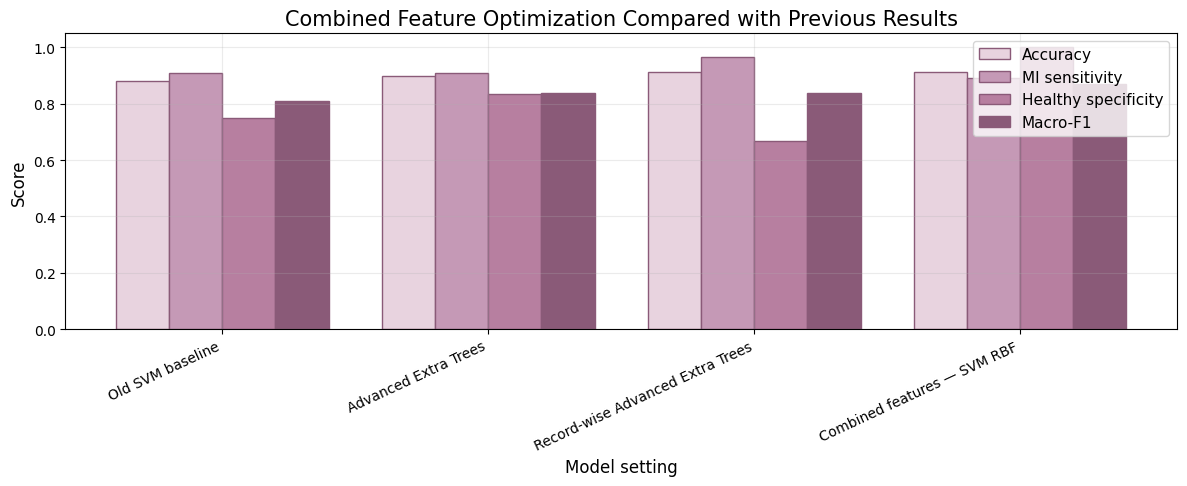

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6D_combined_feature_comparison.png


In [25]:
plot_df = comparison_df.copy()

x = np.arange(len(plot_df))
width = 0.2

plt.figure(figsize=(12, 5))

plt.bar(
    x - 1.5 * width,
    plot_df["accuracy"],
    width,
    label="Accuracy",
    color=PURPLE_LIGHT,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x - 0.5 * width,
    plot_df["recall_sensitivity_mi"],
    width,
    label="MI sensitivity",
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x + 0.5 * width,
    plot_df["specificity_healthy"],
    width,
    label="Healthy specificity",
    color=PURPLE_MID,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x + 1.5 * width,
    plot_df["macro_f1"],
    width,
    label="Macro-F1",
    color=PURPLE_DARK,
    edgecolor=PURPLE_DARK
)

plt.title("Combined Feature Optimization Compared with Previous Results")
plt.xlabel("Model setting")
plt.ylabel("Score")
plt.xticks(x, plot_df["setting"], rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()

fig_path = FIGURE_DIR / "notebook6D_combined_feature_comparison.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

In [26]:
selector = best_pipe.named_steps["select"]
selected_mask = selector.get_support()

selected_features = np.array(best_cols)[selected_mask]
selected_scores = selector.scores_[selected_mask]

selected_feature_df = pd.DataFrame({
    "feature": selected_features,
    "anova_f_score": selected_scores
}).sort_values("anova_f_score", ascending=False)

print("Number of selected features:", len(selected_feature_df))
display(selected_feature_df.head(50))

selected_feature_path = TABLE_DIR / "notebook6D_selected_combined_features.csv"
selected_feature_df.to_csv(selected_feature_path, index=False, encoding="utf-8-sig")

print("Saved:", selected_feature_path)

Number of selected features: 500


,feature,anova_f_score
444,old__limb_group_morph_t_amp_mean_mean,84.116581
57,old__v5_stat_median,76.475812
174,old__avr_morph_t_amp_max,73.160027
62,old__v6_stat_median,72.710223
52,old__v4_stat_median,70.690804
360,old__v5_morph_baseline_median,69.259744
359,old__v5_morph_baseline_mean,69.027493
138,old__iii_morph_qrs_max_amp_mean,67.682800
61,old__v5_stat_zcr,66.971122
139,old__iii_morph_qrs_max_amp_median,66.849578


Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook6D_selected_combined_features.csv


,feature_source,n_selected_features
0,old_handcrafted,500


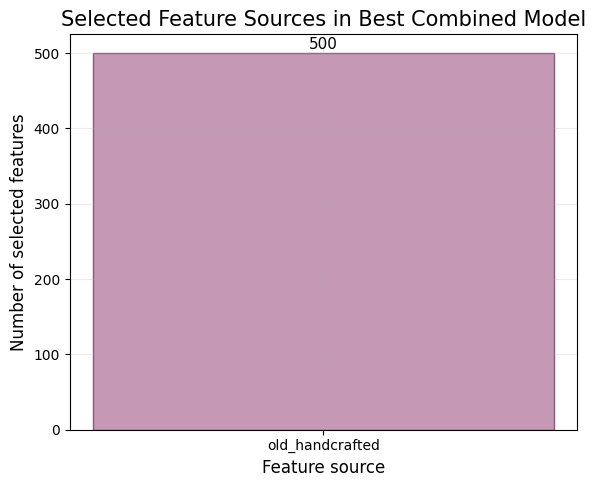

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6D_selected_feature_sources.png


In [28]:
selected_feature_df["source"] = np.where(
    selected_feature_df["feature"].str.startswith("old__"),
    "old_handcrafted",
    "advanced_fiducial"
)

selected_source_counts = selected_feature_df["source"].value_counts().reset_index()
selected_source_counts.columns = ["feature_source", "n_selected_features"]

display(selected_source_counts)

plt.figure(figsize=(6, 5))

bars = plt.bar(
    selected_source_counts["feature_source"],
    selected_source_counts["n_selected_features"],
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.title("Selected Feature Sources in Best Combined Model")
plt.xlabel("Feature source")
plt.ylabel("Number of selected features")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        str(int(height)),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

fig_path = FIGURE_DIR / "notebook6D_selected_feature_sources.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)